(685, 18)


C:\Users\alarokia\AppData\Local\Temp\ipykernel_28616\3174412257.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


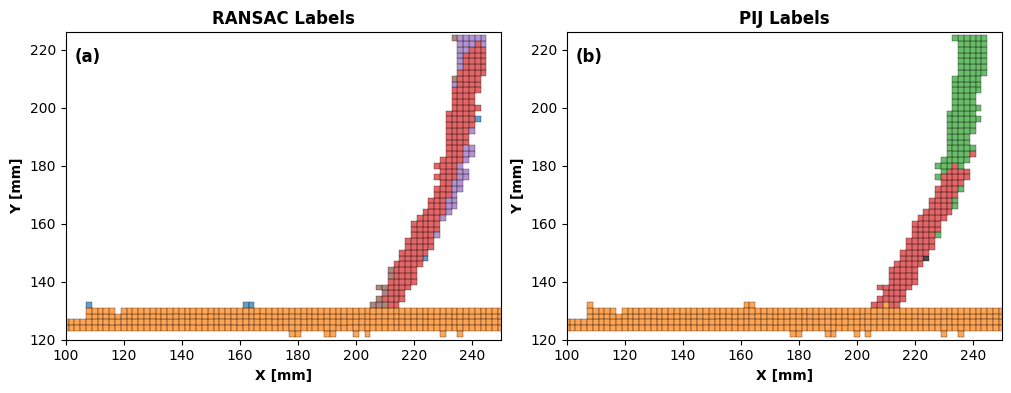

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm

# Load the data
data = np.load('sim_10mev_5cm_event1323.npy')

print(data.shape)

# Extract coordinates and labels
x = data[:, 0]
y = data[:, 1]
pij_labels = data[:, 10].astype(int)
ransac_labels = data[:, 7].astype(int)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

# Colormap
cmap = cm.get_cmap('tab10')

# --- Plot 1: RANSAC labels ---
unique_ransac = np.unique(ransac_labels)
for k in unique_ransac:
    subset = (ransac_labels == k)
    color = 'k' if k == -1 else cmap(k % 10)
    for xi, yi in zip(x[subset], y[subset]):
        rect = Rectangle((xi - 1, yi - 1), 2, 2, facecolor=color,
                         edgecolor='k', alpha=0.7, linewidth=0.3)
        axes[0].add_patch(rect)

axes[0].set_title("RANSAC Labels", fontweight='bold')
axes[0].set_xlabel("X [mm]", fontweight='bold')
axes[0].set_ylabel("Y [mm]", fontweight='bold')
axes[0].set_aspect('equal')
# axes[0].set_xlim(np.min(x) - 2, np.max(x) + 2)
axes[0].set_xlim(100, 250)
axes[0].set_ylim(np.min(y) - 2, np.max(y) + 2)

# --- Plot 2: PIJ labels ---
unique_pij = np.unique(pij_labels)
for k in unique_pij:
    subset = (pij_labels == k)
    color = 'k' if k == -1 else cmap(k % 10)
    for xi, yi in zip(x[subset], y[subset]):
        rect = Rectangle((xi - 1, yi - 1), 2, 2, facecolor=color,
                         edgecolor='k', alpha=0.7, linewidth=0.3)
        axes[1].add_patch(rect)

axes[1].set_title("PIJ Labels", fontweight='bold')
axes[1].set_xlabel("X [mm]", fontweight='bold')
axes[1].set_ylabel("Y [mm]", fontweight='bold')
axes[1].set_aspect('equal')
# axes[1].set_xlim(np.min(x) - 2, np.max(x) + 2)
axes[1].set_xlim(100, 250)
axes[1].set_ylim(np.min(y) - 2, np.max(y) + 2)

# Label subplots (a), (b)
labels = ['(a)', '(b)']
for ax, label in zip(axes, labels):
    ax.text(0.02, 0.95, label, transform=ax.transAxes, fontsize=12,
            fontweight='bold', va='top', ha='left')

# Save as publication-quality EPS
# fig.savefig("xy_projection_ransac_pij.eps", format='eps', dpi=300)
plt.show()




C:\Users\alarokia\AppData\Local\Temp\ipykernel_28616\674732829.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


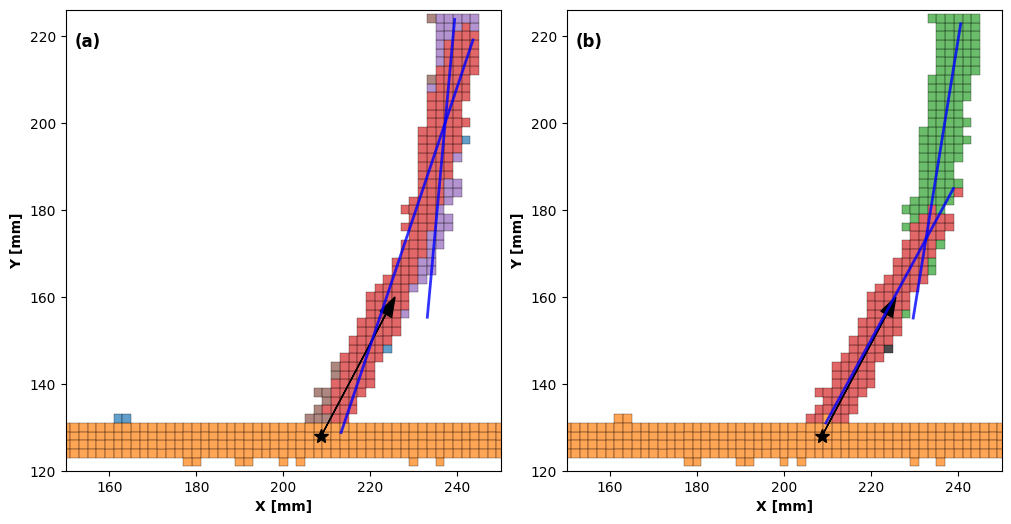

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm

# Load the data
data = np.load('sim_10mev_5cm_event1323.npy')
x = data[:, 0]
y = data[:, 1]
pij_labels = data[:, 10].astype(int)
ransac_labels = data[:, 7].astype(int)

# ---- Define Fit Line Segments ----
# RANSAC segments
ransac_segments = [
    ([213.28724423, 128.78716928, 129.88737766],
     [243.60123458, 219.00185767, 216.02107128]),
    ([233.10662325, 155.28952901, 162.79850451],
     [239.3832326,  223.73167966, 214.65236703])
]

# GMM segments
gmm_segments = [
    ([240.58289486, 222.73389861, 215.44977913],
     [229.66804835, 155.09819228, 163.29934863]),
    ([238.89582001, 184.83796653, 186.49526595],
     [209.58991972, 130.96554428, 129.76629564])
]

# Vertex and direction
vertex = np.array([208.68, 127.94, 127.98])
direction = np.array([0.34, 0.64, -0.68])

# ---- Create Figure ----
fig, axes = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)
cmap = cm.get_cmap('tab10')

# Helper function to draw squares
def draw_squares(ax, x, y, labels, title):
    unique_labels = np.unique(labels)
    for k in unique_labels:
        subset = (labels == k)
        color = 'k' if k == -1 else cmap(k % 10)
        for xi, yi in zip(x[subset], y[subset]):
            rect = Rectangle((xi - 1, yi - 1), 2, 2,
                             facecolor=color, edgecolor='k',
                             alpha=0.7, linewidth=0.3)
            ax.add_patch(rect)
    # ax.set_title(title, fontweight='bold')
    ax.set_xlabel("X [mm]", fontweight='bold')
    ax.set_ylabel("Y [mm]", fontweight='bold')
    ax.set_aspect('equal')
    # ax.set_xlim(np.min(x) - 2, np.max(x) + 2)
    # ax.set_ylim(np.min(y) - 2, np.max(y) + 2)
    ax.set_xlim(150, 250)
    ax.set_ylim(np.min(y) - 2, np.max(y) + 2)

# ---- Plot RANSAC subplot ----
ax_ransac = axes[0]
draw_squares(ax_ransac, x, y, ransac_labels, "RANSAC Labels")

# # Plot RANSAC line segments (XY projection)
# for start, end in ransac_segments:
#     ax_ransac.plot([start[0], end[0]], [start[1], end[1]], 'r-', lw=2)

# Plot RANSAC line segments (XY projection)
for start, end in ransac_segments:
    ax_ransac.plot(
        [start[0], end[0]], [start[1], end[1]],
        color='blue',        # grey color
        lw=2,                # line width
        alpha=0.8,           # transparency (0 = transparent, 1 = opaque)
        linestyle='-'        # solid line
    )


# Plot vertex and direction
# Plot vertex (black star) and extended direction vector (length 50)
ax_ransac.plot(vertex[0], vertex[1], 'k*', markersize=10, label='Vertex')
ax_ransac.arrow(vertex[0], vertex[1],
                50 * direction[0], 50 * direction[1],
                head_width=3, color='black', length_includes_head=True)

# ---- Plot GMM subplot ----
ax_gmm = axes[1]
draw_squares(ax_gmm, x, y, pij_labels, "GMM (PIJ) Labels")

# Plot GMM line segments (XY projection)
for start, end in gmm_segments:
    ax_gmm.plot([start[0], end[0]], [start[1], end[1]], 'b-', lw=2, alpha=0.8)

# Plot vertex and direction
ax_gmm.plot(vertex[0], vertex[1], 'k*', markersize=10)
ax_gmm.arrow(vertex[0], vertex[1],
             50 * direction[0], 50 * direction[1],
             head_width=3, color='black', length_includes_head=True)

# Label subplots (a), (b)
labels = ['(a)', '(b)']
for ax, label in zip(axes, labels):
    ax.text(0.02, 0.95, label, transform=ax.transAxes, fontsize=12,
            fontweight='bold', va='top', ha='left')

# ---- Save publication-quality EPS ----
fig.savefig("xy_projection_ransac_gmm_tracks.eps", format='eps', dpi=300)
plt.show()
